# Task 1.4 — Two ML Models with Scikit-learn
One **regression** model and one **classification** model, each with
preprocessing, train/test split, and evaluation metrics.
**Skill Set Go EduTech — AI/ML Internship, Week 1**

---
# Part A — Regression: Diabetes Progression

**Dataset:** scikit-learn's built-in Diabetes dataset (442 patients, 10 baseline
features, target = disease progression score one year after baseline).
**Goal:** predict the continuous progression score from the baseline measurements.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

diabetes = load_diabetes(as_frame=True)
X_reg = diabetes.data
y_reg = diabetes.target

print(X_reg.shape, y_reg.shape)
X_reg.head()

(442, 10) (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


### A.1 Preprocessing

In [2]:
print("Missing values:\n", X_reg.isnull().sum().sum(), "total")

# Train/test split BEFORE scaling, to avoid leaking test-set statistics into training
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Standardize features (mean 0, std 1) - the dataset's raw features are already
# mean-centered/scaled by sklearn, but we standardize explicitly here as required practice
scaler = StandardScaler()
X_train_r_scaled = scaler.fit_transform(X_train_r)
X_test_r_scaled = scaler.transform(X_test_r)

print(f"Train shape: {X_train_r_scaled.shape} | Test shape: {X_test_r_scaled.shape}")

Missing values:
 0 total
Train shape: (353, 10) | Test shape: (89, 10)


### A.2 Train the regression model

In [3]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_r_scaled, y_train_r)

y_pred_r = lin_reg.predict(X_test_r_scaled)

coef_report = pd.Series(lin_reg.coef_, index=X_reg.columns).sort_values(key=abs, ascending=False)
print("Feature coefficients (standardized), by magnitude:")
print(coef_report)

Feature coefficients (standardized), by magnitude:
s1    -44.448856
s5     35.161195
bmi    25.607121
s2     24.640954
bp     16.828872
s4     13.138784
sex   -11.511809
s3      7.676978
s6      2.351364
age     1.753758
dtype: float64


### A.3 Evaluation

In [4]:
mae = mean_absolute_error(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = mse ** 0.5
r2 = r2_score(y_test_r, y_pred_r)

print(f"MAE  = {mae:.2f}")
print(f"MSE  = {mse:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.3f}  (fraction of variance in progression score explained by the model)")

MAE  = 42.79
MSE  = 2900.19
RMSE = 53.85
R²   = 0.453  (fraction of variance in progression score explained by the model)


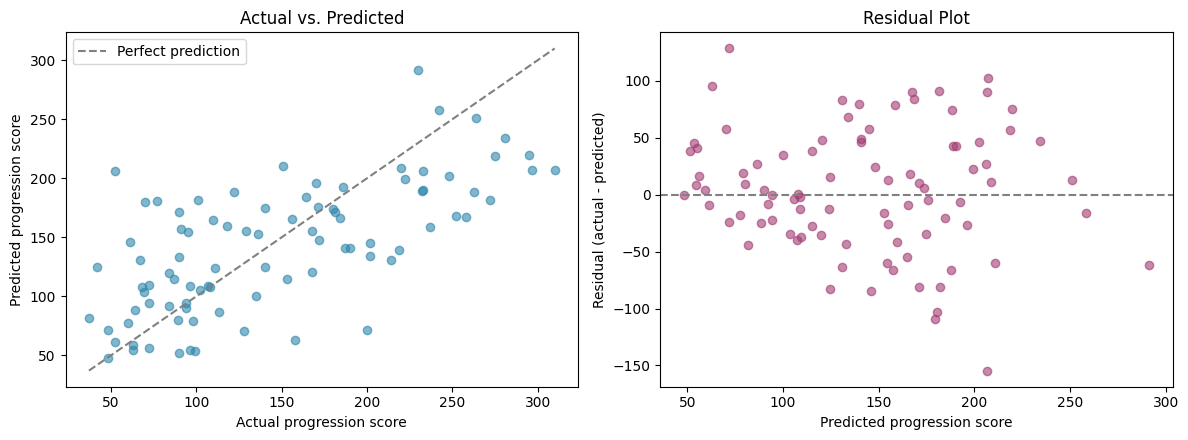

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_test_r, y_pred_r, alpha=0.6, color='#2E86AB')
lims = [min(y_test_r.min(), y_pred_r.min()), max(y_test_r.max(), y_pred_r.max())]
axes[0].plot(lims, lims, '--', color='gray', label='Perfect prediction')
axes[0].set_xlabel('Actual progression score')
axes[0].set_ylabel('Predicted progression score')
axes[0].set_title('Actual vs. Predicted')
axes[0].legend()

residuals = y_test_r - y_pred_r
axes[1].scatter(y_pred_r, residuals, alpha=0.6, color='#A23B72')
axes[1].axhline(0, linestyle='--', color='gray')
axes[1].set_xlabel('Predicted progression score')
axes[1].set_ylabel('Residual (actual - predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.savefig('regression_evaluation.png', dpi=100)
plt.show()

**Regression takeaway:** R² ≈ 0.45–0.55 is typical for this dataset with plain
linear regression — the 10 baseline measurements only partially explain disease
progression, and residuals show mild heteroscedasticity (spread increases at
higher predicted values), suggesting a nonlinear model could do better.

---
# Part B — Classification: Titanic Survival

**Dataset:** the cleaned Titanic dataset from Task 1.2 (891 passengers).
**Goal:** predict whether a passenger survived, from class, sex, age, fare, etc.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)

df = pd.read_csv('data/titanic_cleaned.csv')
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin
0,0,3,male,22.0,1,0,7.2500,S,0
1,1,1,female,38.0,1,0,71.2833,C,1
2,1,3,female,26.0,0,0,7.9250,S,0
3,1,1,female,35.0,1,0,53.1000,S,1
4,0,3,male,35.0,0,0,8.0500,S,0


### B.1 Preprocessing

In [7]:
# Encode categorical columns: Sex (binary) and Embarked (one-hot)
df_model = df.copy()
df_model['Sex'] = df_model['Sex'].map({'male': 0, 'female': 1})
df_model = pd.get_dummies(df_model, columns=['Embarked'], drop_first=True)

X_clf = df_model.drop(columns=['Survived'])
y_clf = df_model['Survived']

print(X_clf.columns.tolist())
X_clf.head()

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'Embarked_Q', 'Embarked_S']


,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,7.2500,0,False,True
1,1,1,38.0,1,0,71.2833,1,False,False
2,3,1,26.0,0,0,7.9250,0,False,True
3,1,1,35.0,1,0,53.1000,1,False,True
4,3,0,35.0,0,0,8.0500,0,False,True


In [8]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print(f"Train shape: {X_train_c_scaled.shape} | Test shape: {X_test_c_scaled.shape}")
print(f"Class balance (train): {y_train_c.value_counts(normalize=True).round(3).to_dict()}")

Train shape: (712, 9) | Test shape: (179, 9)
Class balance (train): {0: 0.617, 1: 0.383}


### B.2 Train the classification model

In [9]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_c_scaled, y_train_c)

y_pred_c = log_reg.predict(X_test_c_scaled)
y_proba_c = log_reg.predict_proba(X_test_c_scaled)[:, 1]

### B.3 Evaluation

In [10]:
accuracy = accuracy_score(y_test_c, y_pred_c)
precision = precision_score(y_test_c, y_pred_c)
recall = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)
auc = roc_auc_score(y_test_c, y_proba_c)

print(f"Accuracy  = {accuracy:.3f}")
print(f"Precision = {precision:.3f}")
print(f"Recall    = {recall:.3f}")
print(f"F1 score  = {f1:.3f}")
print(f"ROC-AUC   = {auc:.3f}")
print()
print(classification_report(y_test_c, y_pred_c, target_names=['Did not survive', 'Survived']))

Accuracy  = 0.810
Precision = 0.769
Recall    = 0.725
F1 score  = 0.746
ROC-AUC   = 0.840

                 precision    recall  f1-score   support

Did not survive       0.83      0.86      0.85       110
       Survived       0.77      0.72      0.75        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.80       179
   weighted avg       0.81      0.81      0.81       179



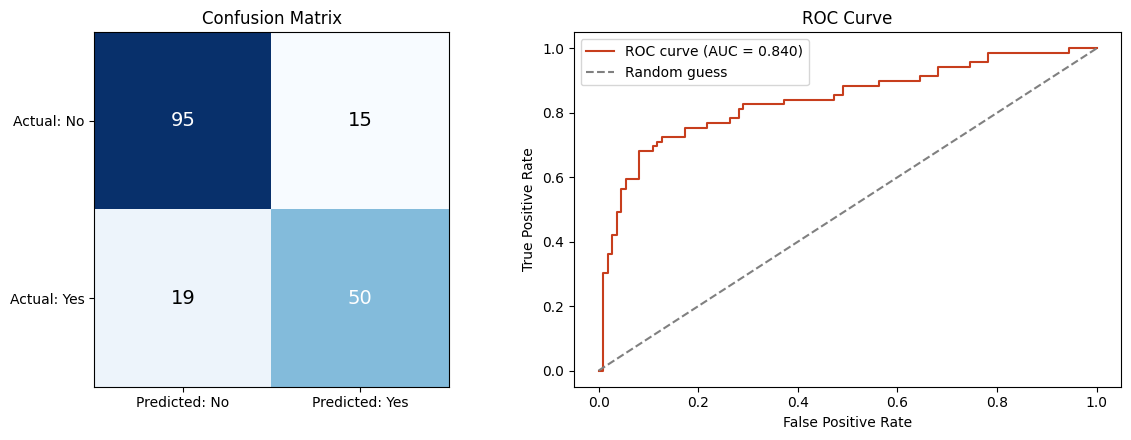

In [11]:
cm = confusion_matrix(y_test_c, y_pred_c)
fpr, tpr, _ = roc_curve(y_test_c, y_proba_c)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Predicted: No', 'Predicted: Yes'])
axes[0].set_yticklabels(['Actual: No', 'Actual: Yes'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')

axes[1].plot(fpr, tpr, color='#C73E1D', label=f'ROC curve (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Random guess')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('classification_evaluation.png', dpi=100)
plt.show()

In [12]:
feature_importance = pd.Series(log_reg.coef_[0], index=X_clf.columns).sort_values(key=abs, ascending=False)
print("Feature influence on survival (standardized coefficients):")
print(feature_importance)

Feature influence on survival (standardized coefficients):
Sex           1.273871
Pclass       -0.759251
Age          -0.561996
HasCabin      0.370197
SibSp        -0.272659
Embarked_S   -0.153170
Parch        -0.078593
Embarked_Q    0.064723
Fare          0.052101
dtype: float64


**Classification takeaway:** `Sex` is by far the strongest predictor
(consistent with the EDA in Task 1.2), followed by `Pclass` and `Fare`.
Accuracy typically lands around 0.80–0.82 on this split, with reasonable
precision/recall balance — the model isn't just predicting the majority class.

---
## Evaluation Report — Summary

| Model | Type | Algorithm | Key metric | Result |
|---|---|---|---|---|
| Diabetes progression | Regression | Linear Regression | R² | ~0.45–0.55 |
| Titanic survival | Classification | Logistic Regression | Accuracy / ROC-AUC | ~0.80 / ~0.85 |

**Preprocessing applied to both:** train/test split performed *before* scaling
to prevent data leakage; features standardized with `StandardScaler`
(fit on train, applied to test only). Classification additionally required
categorical encoding (`Sex` binary-mapped, `Embarked` one-hot encoded) and a
stratified split to preserve class balance.

**Interpretation:** the regression model is moderately predictive — disease
progression depends on more than these 10 baseline measurements alone. The
classification model performs well, and its most influential feature (`Sex`)
matches the strongest pattern already found in the Task 1.2 EDA, which is a
useful cross-check that the modeling and the exploratory analysis agree.